# Synthetic Two-Objective Reservoir Case Study

This notebook demonstrates Fitted Q-Iteration (FQI) and Multi-Objective Fitted Q-Iteration (MOFQI) on the stationary synthetic reservoir problem described by Pianosi, Castelletti and Restelli (2013).

The reservoir has two conflicting objectives:

1. Minimise flooding above the reservoir-level threshold.
2. Minimise irrigation supply deficits.

Repeated FQI training is performed separately for each prescribed objective-weight combination. MOFQI uses one weight-conditioned training process.

This is a compact methodological reproduction. It uses standard scikit-learn Extra Trees and reduced experimental settings so that it can run on a personal computer. It does not attempt to reproduce the paper's exact numerical results or its customised tree-pruning procedure.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mofqi_reservoir import (
    SyntheticReservoir,
    evaluate_fqi_policy,
    evaluate_mofqi_policy,
    sample_reservoir_transitions,
    train_fqi_mofqi_comparison,
)

plt.style.use("seaborn-v0_8-whitegrid")

In [11]:
RANDOM_STATE = 42
N_SAMPLES = 1_000
N_ITERATIONS = 10
N_ESTIMATORS = 20
EPISODE_LENGTH = 10
N_EVALUATION_EPISODES = 20

CANDIDATE_ACTIONS = np.linspace(0.0, 160.0, 33)

FLOOD_WEIGHTS = np.linspace(0.0, 1.0, 11)
WEIGHTS = np.column_stack(
    (FLOOD_WEIGHTS, 1.0 - FLOOD_WEIGHTS)
)

configuration = pd.Series(
    {
        "Offline transitions": N_SAMPLES,
        "Preference combinations": len(WEIGHTS),
        "Candidate actions": len(CANDIDATE_ACTIONS),
        "FQI iterations": N_ITERATIONS,
        "Extra Trees per iteration": N_ESTIMATORS,
        "Evaluation episodes": N_EVALUATION_EPISODES,
        "Episode length": EPISODE_LENGTH,
    },
    name="Value",
)

configuration

Offline transitions          1000
Preference combinations        11
Candidate actions              33
FQI iterations                 10
Extra Trees per iteration      20
Evaluation episodes            20
Episode length                 10
Name: Value, dtype: int64

In [12]:
batch = sample_reservoir_transitions(
    n_samples=N_SAMPLES,
    random_state=RANDOM_STATE,
)

transition_data = pd.DataFrame(
    {
        "storage": batch.states[:, 0],
        "release_decision": batch.actions[:, 0],
        "next_storage": batch.next_states[:, 0],
        "flood_reward": batch.rewards[:, 0],
        "irrigation_reward": batch.rewards[:, 1],
    }
)

transition_data.describe().round(2)

,storage,release_decision,next_storage,flood_reward,irrigation_reward
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,77.06,81.36,63.42,-19.53,-13.06
std,45.20,46.29,34.51,29.71,15.99
min,0.19,0.08,11.38,-117.67,-49.83
25%,37.24,39.92,39.45,-32.98,-26.11
50%,76.70,79.44,50.25,-0.25,-2.80
75%,117.63,122.09,82.98,0.00,0.00
max,154.86,159.91,167.67,-0.00,-0.00


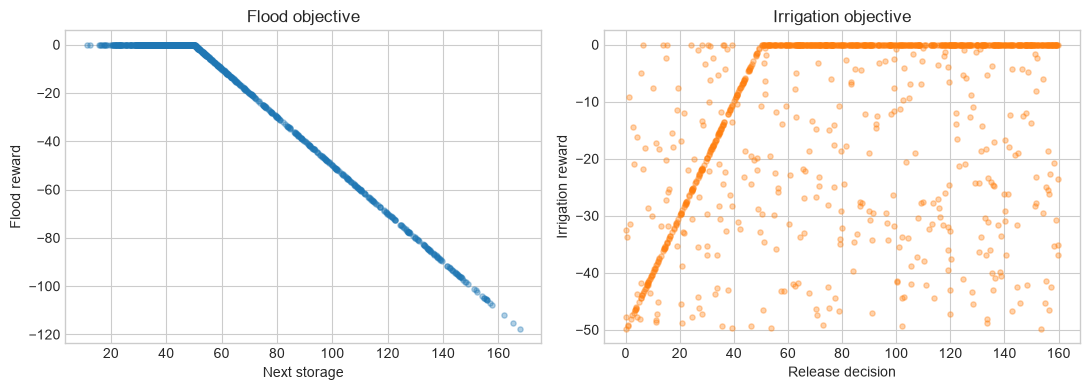

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(
    transition_data["next_storage"],
    transition_data["flood_reward"],
    alpha=0.35,
    s=14,
)
axes[0].set_xlabel("Next storage")
axes[0].set_ylabel("Flood reward")
axes[0].set_title("Flood objective")

axes[1].scatter(
    transition_data["release_decision"],
    transition_data["irrigation_reward"],
    alpha=0.35,
    s=14,
    color="tab:orange",
)
axes[1].set_xlabel("Release decision")
axes[1].set_ylabel("Irrigation reward")
axes[1].set_title("Irrigation objective")

plt.tight_layout()
plt.show()

In [14]:
comparison = train_fqi_mofqi_comparison(
    batch=batch,
    weights=WEIGHTS,
    candidate_actions=CANDIDATE_ACTIONS,
    gamma=1.0,
    n_iterations=N_ITERATIONS,
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

training_times = pd.Series(
    {
        f"Repeated FQI ({comparison.n_weights} models)": (
            comparison.fqi_training_seconds
        ),
        "Single MOFQI process": comparison.mofqi_training_seconds,
    },
    name="Training time (seconds)",
)

training_times.round(3)

Repeated FQI (11 models)    3.808
Single MOFQI process        3.390
Name: Training time (seconds), dtype: float64

In [15]:
def evaluate_preference(weight_index, weight):
    """Evaluate FQI and MOFQI under identical inflow seeds."""
    fqi_episode_returns = []
    mofqi_episode_returns = []

    for episode in range(N_EVALUATION_EPISODES):
        episode_seed = 10_000 + episode

        fqi_environment = SyntheticReservoir(
            initial_storage=50.0,
            episode_length=EPISODE_LENGTH,
            random_state=episode_seed,
        )
        mofqi_environment = SyntheticReservoir(
            initial_storage=50.0,
            episode_length=EPISODE_LENGTH,
            random_state=episode_seed,
        )

        fqi_result = evaluate_fqi_policy(
            environment=fqi_environment,
            learner=comparison.fqi_learners[weight_index],
            max_steps=EPISODE_LENGTH,
            gamma=1.0,
        )
        mofqi_result = evaluate_mofqi_policy(
            environment=mofqi_environment,
            learner=comparison.mofqi_learner,
            weights=weight,
            max_steps=EPISODE_LENGTH,
            gamma=1.0,
        )

        fqi_episode_returns.append(fqi_result.objective_returns)
        mofqi_episode_returns.append(mofqi_result.objective_returns)

    return (
        np.mean(fqi_episode_returns, axis=0),
        np.mean(mofqi_episode_returns, axis=0),
    )


fqi_returns = []
mofqi_returns = []

for weight_index, weight in enumerate(WEIGHTS):
    print(
        f"Evaluating flood weight {weight[0]:.1f} "
        f"({weight_index + 1}/{len(WEIGHTS)})"
    )

    fqi_mean, mofqi_mean = evaluate_preference(
        weight_index,
        weight,
    )

    fqi_returns.append(fqi_mean)
    mofqi_returns.append(mofqi_mean)

fqi_returns = np.asarray(fqi_returns)
mofqi_returns = np.asarray(mofqi_returns)

Evaluating flood weight 0.0 (1/11)
Evaluating flood weight 0.1 (2/11)
Evaluating flood weight 0.2 (3/11)
Evaluating flood weight 0.3 (4/11)
Evaluating flood weight 0.4 (5/11)
Evaluating flood weight 0.5 (6/11)
Evaluating flood weight 0.6 (7/11)
Evaluating flood weight 0.7 (8/11)
Evaluating flood weight 0.8 (9/11)
Evaluating flood weight 0.9 (10/11)
Evaluating flood weight 1.0 (11/11)


In [16]:
results = pd.DataFrame(
    {
        "flood_weight": FLOOD_WEIGHTS,
        "irrigation_weight": 1.0 - FLOOD_WEIGHTS,
        "fqi_flood_return": fqi_returns[:, 0],
        "fqi_irrigation_return": fqi_returns[:, 1],
        "mofqi_flood_return": mofqi_returns[:, 0],
        "mofqi_irrigation_return": mofqi_returns[:, 1],
    }
)

results.round(3)

,flood_weight,irrigation_weight,fqi_flood_return,fqi_irrigation_return,mofqi_flood_return,mofqi_irrigation_return
0,0.0,1.0,-12.477,-90.438,-10.597,-88.784
1,0.1,0.9,-13.212,-89.227,-11.542,-89.405
2,0.2,0.8,-9.832,-91.336,-10.386,-90.862
3,0.3,0.7,-9.736,-91.308,-9.670,-91.121
4,0.4,0.6,-10.071,-91.082,-9.883,-92.240
5,0.5,0.5,-9.404,-93.307,-8.875,-93.980
6,0.6,0.4,-9.686,-92.890,-9.727,-93.074
7,0.7,0.3,-8.863,-93.793,-9.480,-93.201
8,0.8,0.2,-8.653,-94.335,-8.833,-94.001
9,0.9,0.1,-8.653,-94.405,-8.653,-94.211


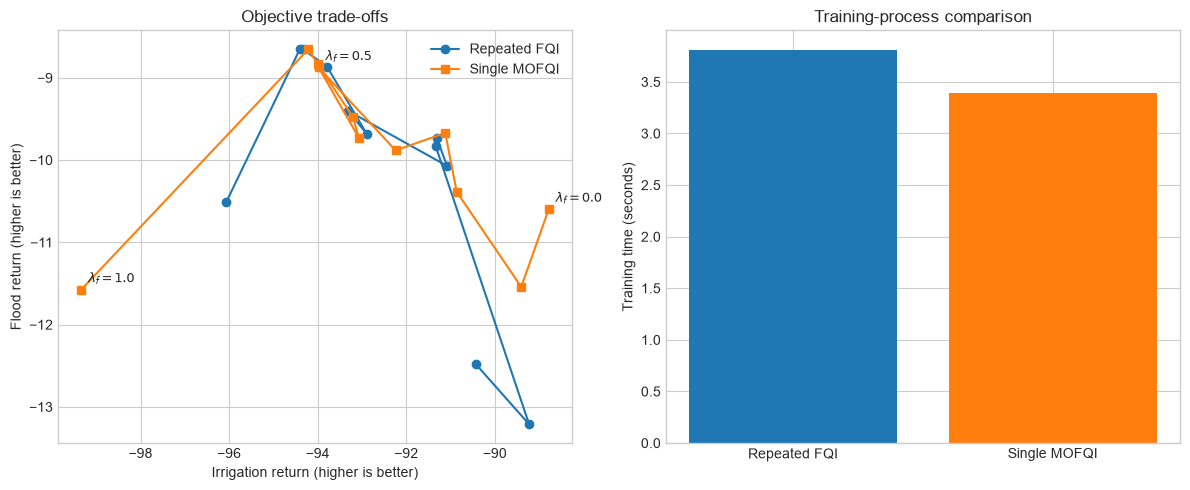

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(
    fqi_returns[:, 1],
    fqi_returns[:, 0],
    marker="o",
    label="Repeated FQI",
)
axes[0].plot(
    mofqi_returns[:, 1],
    mofqi_returns[:, 0],
    marker="s",
    label="Single MOFQI",
)

for index in [0, 5, 10]:
    axes[0].annotate(
        f"$\\lambda_f={FLOOD_WEIGHTS[index]:.1f}$",
        (
            mofqi_returns[index, 1],
            mofqi_returns[index, 0],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

axes[0].set_xlabel("Irrigation return (higher is better)")
axes[0].set_ylabel("Flood return (higher is better)")
axes[0].set_title("Objective trade-offs")
axes[0].legend()

axes[1].bar(
    ["Repeated FQI", "Single MOFQI"],
    [
        comparison.fqi_training_seconds,
        comparison.mofqi_training_seconds,
    ],
    color=["tab:blue", "tab:orange"],
)
axes[1].set_ylabel("Training time (seconds)")
axes[1].set_title("Training-process comparison")

plt.tight_layout()
plt.show()

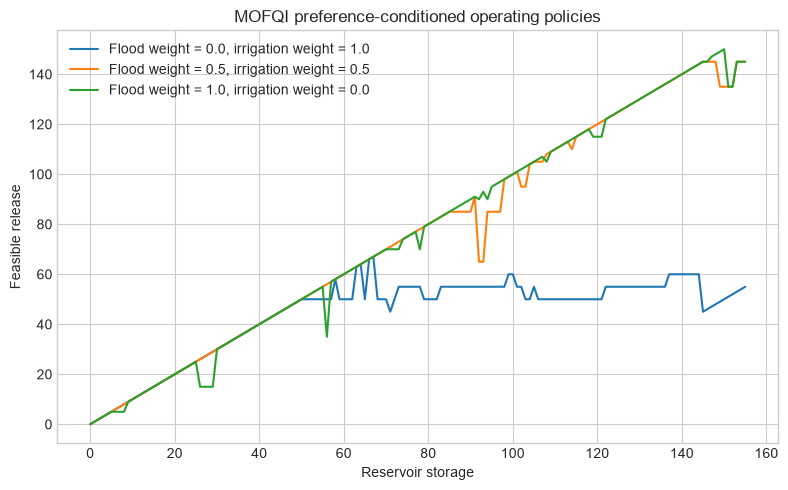

In [18]:
storage_grid = np.linspace(0.0, 155.0, 156)

fig, ax = plt.subplots(figsize=(8, 5))

for flood_weight in [0.0, 0.5, 1.0]:
    preference = [flood_weight, 1.0 - flood_weight]

    selected_decisions = comparison.mofqi_learner.select_actions(
        states=storage_grid,
        weights=preference,
    )[:, 0]

    minimum_releases = np.maximum(
        storage_grid - 100.0,
        0.0,
    )
    maximum_releases = storage_grid

    feasible_releases = np.maximum(
        minimum_releases,
        np.minimum(selected_decisions, maximum_releases),
    )

    ax.plot(
        storage_grid,
        feasible_releases,
        label=(
            f"Flood weight = {flood_weight:.1f}, "
            f"irrigation weight = {1.0 - flood_weight:.1f}"
        ),
    )

ax.set_xlabel("Reservoir storage")
ax.set_ylabel("Feasible release")
ax.set_title("MOFQI preference-conditioned operating policies")
ax.legend()

plt.tight_layout()
plt.show()

## Interpretation

The experiment demonstrates the methodological distinction between the two approaches:

- Repeated FQI trains a separate action-value approximation for every objective-weight combination.
- MOFQI enlarges the state representation with the objective preference and trains one weight-conditioned approximation.
- Both methods produce operating policies that can be evaluated using the original, separate flood and irrigation rewards.
- The objective-return plot shows the evaluated trade-off points obtained by the learned policies. Under this reduced experimental configuration, the points are not guaranteed to be non-dominated or to form an accurate Pareto frontier.
- The timing comparison contrasts multiple FQI training processes with one MOFQI process.

Differences from the published numerical results are expected because this notebook uses fewer offline transitions, a coarser action grid and standard scikit-learn Extra Trees without the paper's customised pruning modification.

The timing comparison is illustrative rather than a formal benchmark. The measured training times were similar in this compact run and may vary between executions. They depend on the hardware, parallel execution, dataset augmentation, number of objective weights and model configuration.